# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

**Sumber Dataset**:  
   https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset?resource=download
   
**Dataset Glossary**:
   - **Customer ID** - Unique identifier for each customer
   - **Age** - Age of the customer
   - **Gender** - Gender of the customer (Male/Female)
   - **Item Purchased** - The item purchased by the customer
   - **Category** - Category of the item purchased
   - **Purchase Amount (USD)** - The amount of the purchase in USD
   - **Location** - Location where the purchase was made
   - **Size** - Size of the purchased item
   - **Color** - Color of the purchased item
   - **Season** - Season during which the purchase was made
   - **Review Rating** - Rating given by the customer for the purchased item
   - **Subscription Status** - Indicates if the customer has a subscription (Yes/No)
   - **Shipping Type** - Type of shipping chosen by the customer
   - **Discount Applied** - Indicates if a discount was applied to the purchase (Yes/No)
   - **Promo Code Used** - Indicates if a promo code was used for the purchase (Yes/No)
   - **Previous Purchases** - The total count of transactions concluded by the customer at the store, excluding the ongoing transaction
   - **Payment Method** - Customer's most preferred payment method
   - **Frequency of Purchases** - Frequency at which the customer makes purchases (e.g., Weekly, Fortnightly, Monthly)



# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset
df = pd.read_csv('../shopping_trends_raw.csv')

# Menampilkan 5 baris pertama
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# Ukuran dataset
print("Jumlah baris dan kolom:", df.shape)

# Informasi dataset
df.info()

# Statistik deskriptif
df.describe()

Jumlah baris dan kolom: (3900, 18)
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used 

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [4]:
# Cek missing values
# Mengidentifikasi bahwa ada fitur yang memerlukan penanganan khusus akibat kekurangan data
print("\nMissing values per fitur:")
print(df.isnull().sum())


Missing values per fitur:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [5]:
# Hapus kolom 
df = df.drop(columns=['Customer ID', 'Promo Code Used' ])
 
# Tampilkan dfFrame untuk memastikan kolom telah dihapus
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

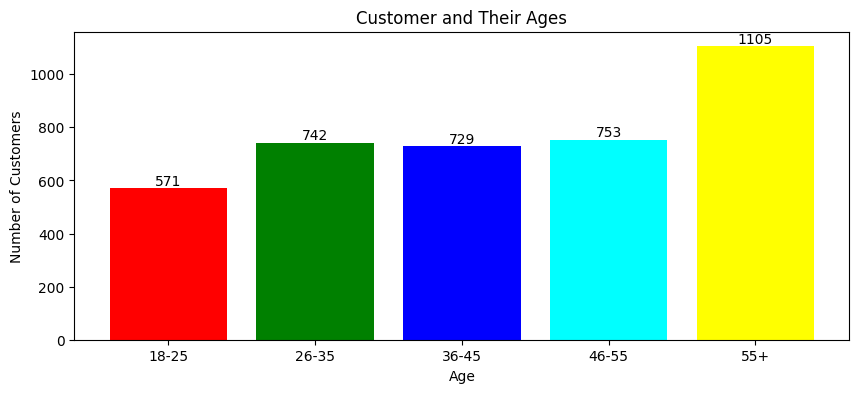

In [6]:
# Mengelompokkan usia pelanggan ke dalam kategori dan menghitung jumlah pelanggan di setiap kategori
age18_25 = df.Age[(df.Age >= 18) & (df.Age <= 25)]
age26_35 = df.Age[(df.Age >= 26) & (df.Age <= 35)]
age36_45 = df.Age[(df.Age >= 36) & (df.Age <= 45)]
age46_55 = df.Age[(df.Age >= 46) & (df.Age <= 55)]
age55above = df.Age[df.Age >= 56]
 
# Menyusun data untuk plotting
x = ["18-25", "26-35", "36-45", "46-55", "55+"]
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values), len(age46_55.values), len(age55above.values)]
 
# Membuat bar chart untuk distribusi usia pelanggan
plt.figure(figsize=(10, 4))
plt.bar(x, y, color=['red', 'green', 'blue', 'cyan', 'yellow'])
plt.title("Customer and Their Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
 
# Menambahkan label jumlah pelanggan di atas setiap bar
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')
 
plt.show()

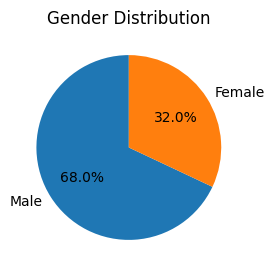

In [7]:
# Menghitung distribusi gender dan menampilkan pie chart untuk visualisasi
plt.figure(figsize=(3, 3))
plt.pie(df['Gender'].value_counts(), labels=['Male', 'Female'], autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

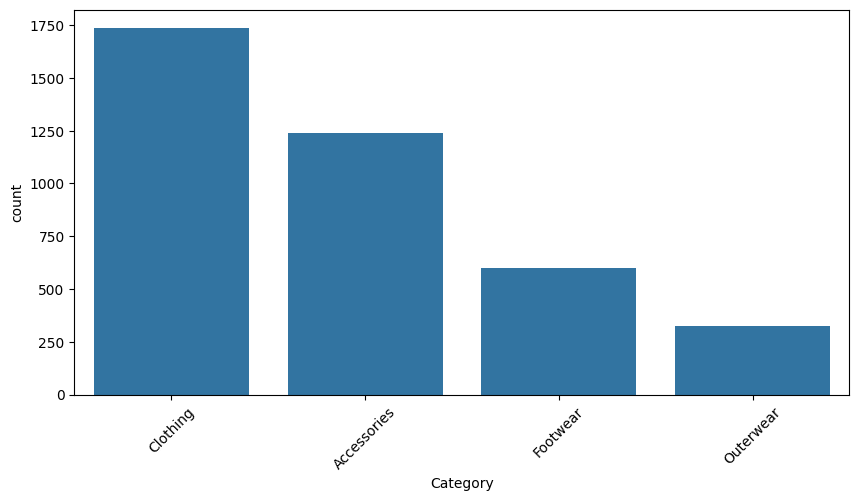

In [8]:
# Distribusi Kategori Produk
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='Category',
    order=df['Category'].value_counts().index
)
plt.xticks(rotation=45)
plt.show()

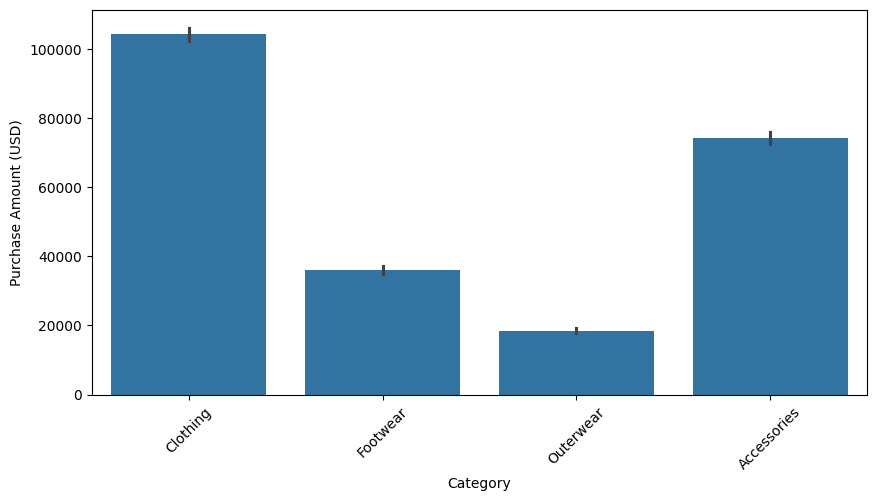

In [9]:
# Total pembelian berdasarkan kategori
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Category',
    y='Purchase Amount (USD)',
    estimator=sum
)

plt.xticks(rotation=45)
plt.show()

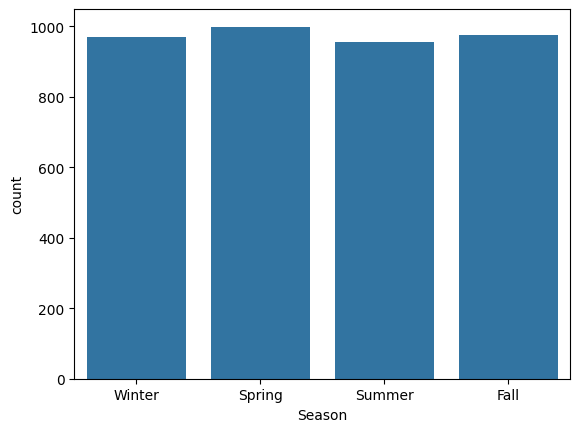

In [10]:
# Distribusi Musim Pembelian
sns.countplot(data=df, x='Season')
plt.show()

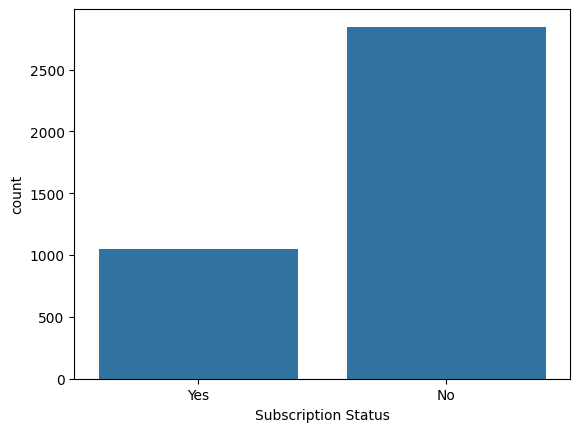

In [11]:
# Subscription status
sns.countplot(data=df, x='Subscription Status')
plt.show()

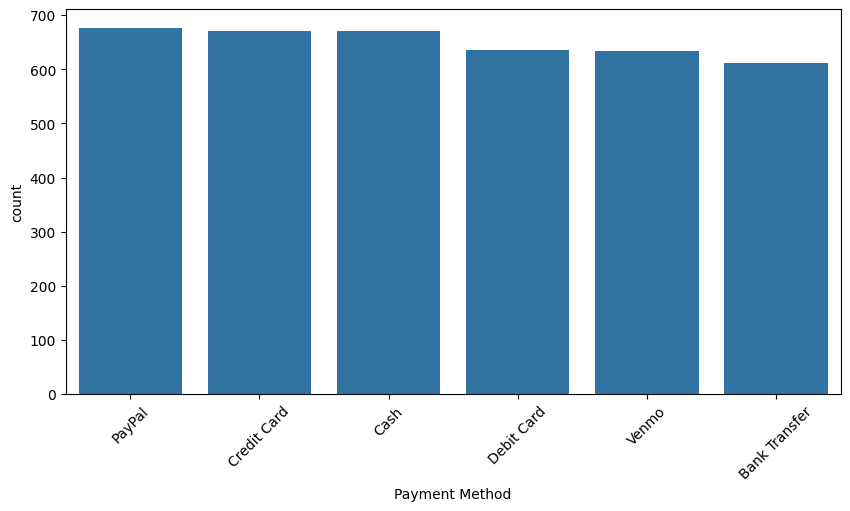

In [12]:
# Metode pembayaran 
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Payment Method',
    order=df['Payment Method'].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

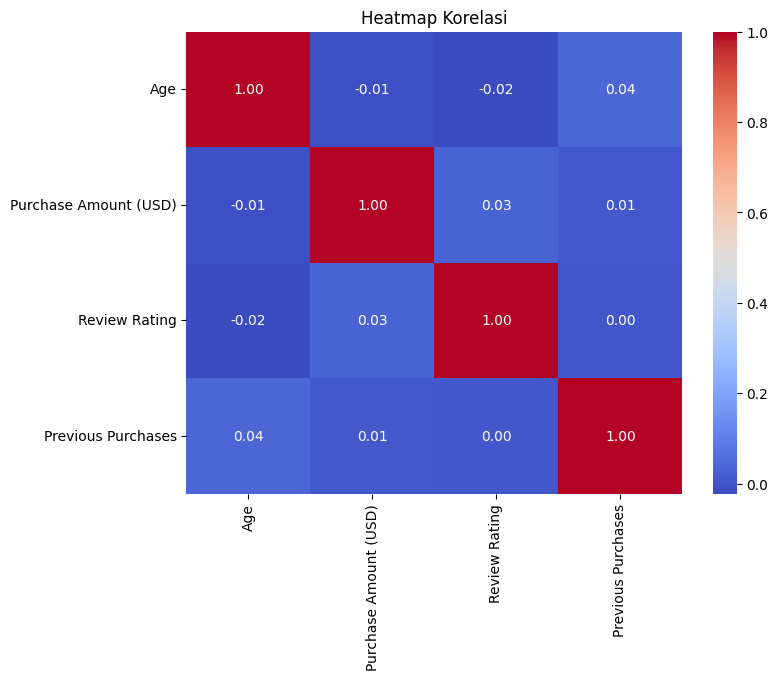

In [13]:
numerical_cols = [
    'Age',
    'Purchase Amount (USD)',
    'Review Rating',
    'Previous Purchases'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
# Cek missing value
df.isnull().sum()

Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [15]:
# Cek data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [16]:
# Hapus duplikat
df = df.drop_duplicates()

In [17]:
numerical_columns = [
    'Age',
    'Purchase Amount (USD)',
    'Review Rating',
    'Previous Purchases'
]

categorical_columns = [
    'Gender',
    'Item Purchased',
    'Category',
    'Location',
    'Size',
    'Color',
    'Season',
    'Subscription Status',
    'Shipping Type',
    'Discount Applied',
    'Payment Method',
    'Frequency of Purchases'
]

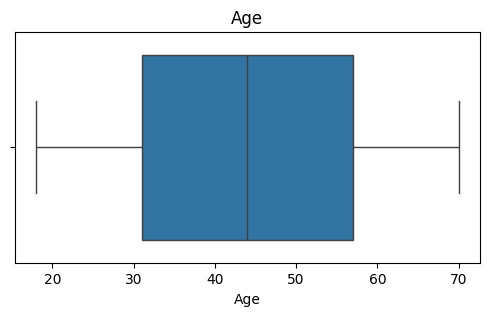

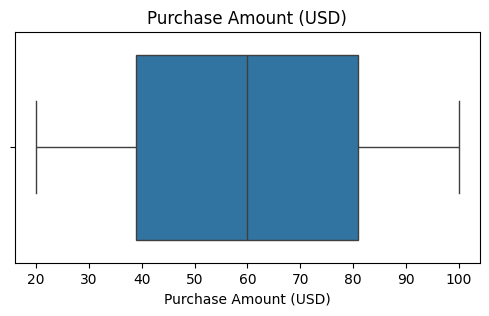

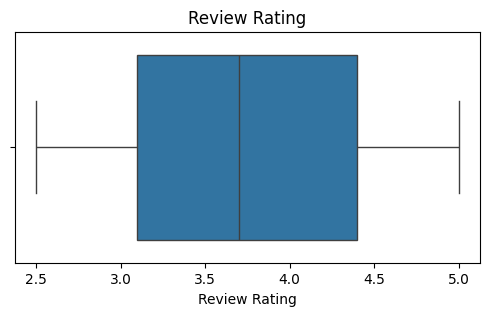

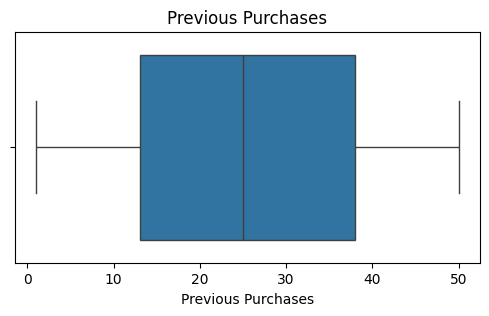

In [18]:
# Deteksi outlier
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [19]:
# Scaling fitur numerik menggunakan MinMaxScaler
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [20]:
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,0.711538,Male,Blouse,Clothing,0.4125,Kentucky,L,Gray,Winter,0.24,Yes,Express,Yes,0.265306,Venmo,Fortnightly
1,0.019231,Male,Sweater,Clothing,0.5500,Maine,L,Maroon,Winter,0.24,Yes,Express,Yes,0.020408,Cash,Fortnightly
2,0.615385,Male,Jeans,Clothing,0.6625,Massachusetts,S,Maroon,Spring,0.24,Yes,Free Shipping,Yes,0.448980,Credit Card,Weekly
3,0.057692,Male,Sandals,Footwear,0.8750,Rhode Island,M,Maroon,Spring,0.40,Yes,Next Day Air,Yes,0.979592,PayPal,Weekly
4,0.519231,Male,Blouse,Clothing,0.3625,Oregon,M,Turquoise,Spring,0.08,Yes,Free Shipping,Yes,0.612245,PayPal,Annually


In [21]:
# Encoding Data Kategorikal
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [22]:
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,0.711538,1,2,1,0.4125,16,0,7,3,0.24,1,1,1,0.265306,5,3
1,0.019231,1,23,1,0.5500,18,0,12,3,0.24,1,1,1,0.020408,1,3
2,0.615385,1,11,1,0.6625,20,2,12,1,0.24,1,2,1,0.448980,2,6
3,0.057692,1,14,2,0.8750,38,1,12,1,0.40,1,3,1,0.979592,4,6
4,0.519231,1,2,1,0.3625,36,1,21,1,0.08,1,2,1,0.612245,4,0


In [23]:
df.to_csv(
    'shopping_trends_preprocessing.csv',
    index=False
)